### 2. Kicking horses

A famous early  application of low-number statistics was an analysis of Prussian cavalryman horse-kick deaths by [Bortkiewicz](https://www.wikiwand.com/en/Ladislaus_Bortkiewicz) in 1898.

He studied the distribution of 122 men kicked to death by horses among 10 Prussian army corps within 20 years (so a total number of corpes of 200). He recorded the number of corps with a given number of deaths:

| Number of deaths | Number of groups |
| --- | --- |
| 0 | 109 |
| 1 | 65 |
| 2 | 22 |
| 3 | 3 |
| 4 | 1 |

- Plot the resulting probability distribution. Careful with the normalization
- How does it look like? Again try to fit it by hand.

(Hint: think about sample mean and sample variance)


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

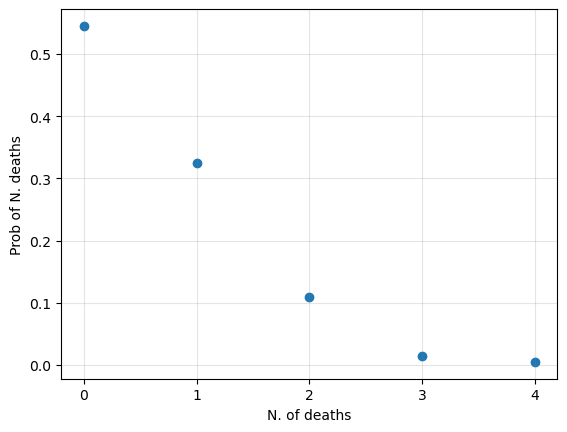

In [2]:
deaths = np.array([0,1,2,3,4])
groups = np.array([109,65,22,3,1])
tot = np.sum(groups)
freq = groups/tot
plt.scatter(deaths, freq)
plt.xlabel('N. of deaths')
plt.ylabel('Prob of N. deaths')
plt.xticks(deaths)
plt.grid(alpha = 0.2, color = 'gray')

It looks like a Poisson distribution! Let's try to fit it 'by hand'

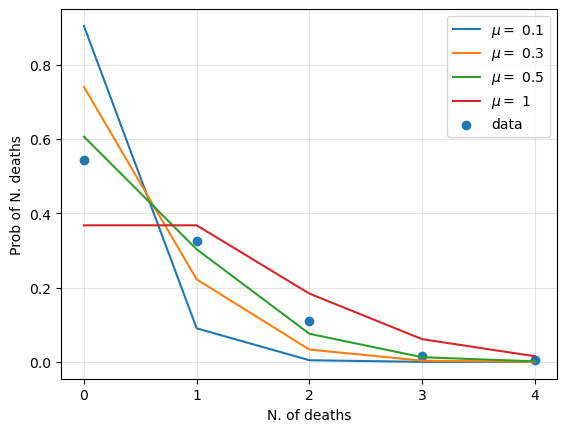

In [3]:
mus = [0.1, 0.3, 0.5, 1]
for i in mus:
    pdf = stats.poisson(i)
    plt.plot(deaths, pdf.pmf(deaths), label = rf'$\mu = $ {i}')

plt.scatter(deaths, freq,label = 'data')
plt.xlabel('N. of deaths')
plt.ylabel('Prob of N. deaths')
plt.xticks(deaths)
plt.legend()
plt.grid(alpha = 0.2, color = 'gray')

To find the 'better' value for $\mu$, we have to compute a mean weighted over the number of deaths!
How do we do it ?

In [4]:
bttr_mu = np.average(deaths, weights=groups)
print('The best mu we should use is:', bttr_mu)

The best mu we should use is: 0.61


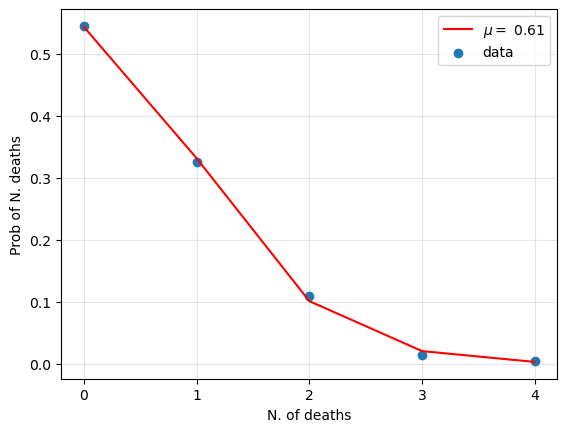

In [5]:
bttr_pdf = stats.poisson(bttr_mu)
plt.plot(deaths, bttr_pdf.pmf(deaths), c = 'red', label = rf'$\mu = $ {bttr_mu}')
plt.scatter(deaths, freq, label = 'data')
plt.grid(alpha = 0.2, color = 'gray')
plt.xlabel('N. of deaths')
plt.ylabel('Prob of N. deaths')
plt.xticks(deaths)
plt.legend()

It works quite nicely!